In [64]:
import gymnasium
import numpy as np
import matplotlib.pyplot as plt

In [65]:
# Q learning
# robot have a goal which give reward
# robot have state and take action, initialize q table from 0,0. q table have states and actions
# in exploitation it chooses max action from q table, in explore, randomly pick an action # this changes state
# next_max = np.max(q_table[new_state]) # exploit
# --- CHOICE SECTION ---
# if random.uniform(0, 1) > epsilon:
#     action = ... # Exploit
# else:
#     action = ... # Explore
# # --- ACTION SECTION ---
# new_state, reward, ... = env.step(action) # State changes here!
# q_table[state, action] = (1 - alpha) * old_value + alpha * (reward + gamma * next_max)
# NewValue = (1 - alpha)*OldValue + alpha*(Reward + gamma*NextMax)

In [66]:
'''
for a grid of 3 by 3
states = np.array(
  [0,1,2],
  [3,4,5],
  [6,7,8]
) # we have obstacle at 5 and reward at 8
# robot can take 4 action
actions = left, right, up, down or 0,1,2,3
'''
# For a 3x3 grid, the Q-table size is 9 rows by 4 columns (a 9x4 matrix).
'''
State (Row)   | Action 0 (Left) | Action 1 (Down) | Action 2 (Right) | Action 3 (Up)
State 0 (0,0) | 0.0             | 0.1             | 0.5              | 0.0
State 1 (0,1) | 0.0             | 0.0             | 0.2              | 0.0
...           | ...             | ...             | ...              | ...
State 8 (2,2) | 0.0             | 0.0             | 0.0              | 0.0
'''


'\nState (Row)   | Action 0 (Left) | Action 1 (Down) | Action 2 (Right) | Action 3 (Up)\nState 0 (0,0) | 0.0             | 0.1             | 0.5              | 0.0\nState 1 (0,1) | 0.0             | 0.0             | 0.2              | 0.0\n...           | ...             | ...             | ...              | ...\nState 8 (2,2) | 0.0             | 0.0             | 0.0              | 0.0\n'

In [67]:
def get_next_state(state, action):
    row = state // 3
    col = state % 3
    if action == 0: row -= 1   # UP
    elif action == 1: row += 1 # DOWN
    elif action == 2: col -= 1 # LEFT
    elif action == 3: col += 1 # RIGHT
    # Boundary check
    if row < 0 or row > 2 or col < 0 or col > 2:
        return state
    return row * 3 + col
# --- Hyperparameters ---
epsilon = 0.5   # Exploration rate
alpha = 0.1     # Learning rate
gamma = 0.9     # Discount factor (usually closer to 0.9 for pathfinding)
episodes = 500  # Train over many "tries" rather than one long run
# --- Initialization ---
q_table = np.zeros((9, 4))
goal_state = 8
actions = [0, 1, 2, 3]
# --- Training Loop ---
for episode in range(episodes):
    state = 0  # Reset to start at the beginning of every episode
    done = False
    while not done:
        # 1. Choose Action (Epsilon-Greedy)
        if np.random.uniform(0, 1) > epsilon:
            action = np.argmax(q_table[state, :]) # Exploit
        else:
            action = np.random.choice(actions)    # Explore
        # 2. Take Action
        next_state = get_next_state(state, action)
        # 3. Calculate Reward
        if next_state == goal_state:
            reward = 10
            done = True # Mark episode as finished
        else:
            reward = -1
            done = False
        # 4. Update Q-Table
        old_value = q_table[state, action]
        if done:
            # If terminal, no future value (next_max is 0)
            q_target = reward
        else:
            # If not terminal, consider future value
            next_max = np.max(q_table[next_state, :])
            q_target = reward + gamma * next_max
        q_table[state, action] = (1 - alpha) * old_value + alpha * q_target
        # 5. Move to next state
        state = next_state

print("Final Q-Table:")
print(q_table)

Final Q-Table:
[[ 3.12179902  4.57792075  3.12140333  4.58      ]
 [ 4.57836519  6.2         3.12110424  6.19601776]
 [ 4.49334637  7.99998238  3.88122474  4.87816702]
 [ 2.68688123  4.27920216  4.42125143  6.19999721]
 [ 4.57713482  7.98360237  4.57933309  8.        ]
 [ 6.16818227 10.          6.19635512  7.99849556]
 [ 1.62540329  1.70863868  1.84029562  7.6697401 ]
 [ 4.68383299  6.56867371  3.76021401  9.99856659]
 [ 0.          0.          0.          0.        ]]


0.07232948812851327
0.19661193324148185
0.534446645388523
0.19661193324148185


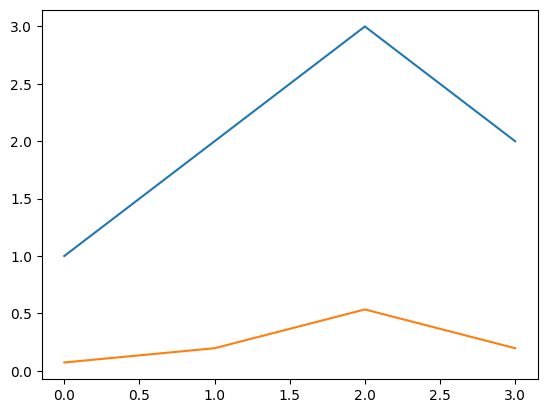

In [70]:
# softmax
t = np.array([0,1,2,3])
z = np.array([1, 2, 3, 2])
total = 0
for i in z:
    total += np.exp(i)
softm = []
for i in z:
    x = np.exp(i) / total
    softm.append(x)
    print(x)

plt.plot(t,z)
plt.plot(t, softm)

In [71]:
import random

# 1. THE BRAIN (Just a variable!)
# Probability of going RIGHT. Start fair at 50%
prob_go_right = 0.5

# 2. THE GAME LOOP
for episode in range(1, 11): # Play 10 games
    print(f"--- Episode {episode} ---")
    print(f"Current Strategy: {100 - prob_go_right*100:.0f}% Left, {prob_go_right*100:.0f}% Right")

    # A. CHOOSE ACTION
    # We roll a dice (0.0 to 1.0)
    dice_roll = random.random()

    if dice_roll < prob_go_right:
        action = "Right"
    else:
        action = "Left"

    # B. PLAY & GET REWARD
    if action == "Right":
        print(f"Robot chose {action}. FOUND GOLD! (+Reward)")
        reward = 1 # Won!
    else:
        print(f"Robot chose {action}. Hit a Wall. (-Reward)")
        reward = -1 # Lost!

    # C. THE UPDATE (The "Nudge")
    # If we won (Reward 1), we want MORE of that probability.
    # If we lost (Reward -1), we want LESS of that probability.

    learning_rate = 0.1 # How big is the nudge?

    if action == "Right":
        # We chose Right.
        # If reward is +1, prob_go_right increases (0.5 -> 0.6)
        # If reward is -1, prob_go_right decreases (0.5 -> 0.4)
        prob_go_right = prob_go_right + (learning_rate * reward)

    elif action == "Left":
        # We chose Left.
        # If reward is +1 (Win), we want MORE Left, so prob_Right goes DOWN.
        # If reward is -1 (Loss), we want LESS Left, so prob_Right goes UP.
        prob_go_right = prob_go_right - (learning_rate * reward)

    # Keep probability between 0 and 1
    prob_go_right = max(0.0, min(1.0, prob_go_right))

print(f"\nFinal Strategy: {prob_go_right*100:.0f}% chance to go Right.")

--- Episode 1 ---
Current Strategy: 50% Left, 50% Right
Robot chose Left. Hit a Wall. (-Reward)
--- Episode 2 ---
Current Strategy: 40% Left, 60% Right
Robot chose Left. Hit a Wall. (-Reward)
--- Episode 3 ---
Current Strategy: 30% Left, 70% Right
Robot chose Left. Hit a Wall. (-Reward)
--- Episode 4 ---
Current Strategy: 20% Left, 80% Right
Robot chose Right. FOUND GOLD! (+Reward)
--- Episode 5 ---
Current Strategy: 10% Left, 90% Right
Robot chose Right. FOUND GOLD! (+Reward)
--- Episode 6 ---
Current Strategy: 0% Left, 100% Right
Robot chose Right. FOUND GOLD! (+Reward)
--- Episode 7 ---
Current Strategy: 0% Left, 100% Right
Robot chose Right. FOUND GOLD! (+Reward)
--- Episode 8 ---
Current Strategy: 0% Left, 100% Right
Robot chose Right. FOUND GOLD! (+Reward)
--- Episode 9 ---
Current Strategy: 0% Left, 100% Right
Robot chose Right. FOUND GOLD! (+Reward)
--- Episode 10 ---
Current Strategy: 0% Left, 100% Right
Robot chose Right. FOUND GOLD! (+Reward)

Final Strategy: 100% chance to 